In [11]:
#Import neccesary required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
#Load the Datasets
train_cleaned = pd.read_csv("train_cleaned.csv")
validation_cleaned = pd.read_csv("validation_cleaned.csv")
test_cleaned = pd.read_csv("test_cleaned.csv")

In [4]:
#Convert Target variables to assist in Modelling
train_cleaned["Reservation_Status"] = train_cleaned["Reservation_Status"].replace({
    "Check-Out":0,
    "Canceled":1,
    "No-Show":1
})

validation_cleaned["Reservation_Status"] = validation_cleaned["Reservation_Status"].replace({
    "Check-Out":0,
    "Canceled":1,
    "No-Show":1
})



In [5]:
#Drop columns that are not required for the model
train_cleaned = train_cleaned.drop(["Booking_date","Expected_checkin","Expected_checkout"],axis=1)
validation_cleaned = validation_cleaned.drop(["Booking_date","Expected_checkin","Expected_checkout"],axis=1)
test_cleaned = test_cleaned.drop(["Booking_date","Expected_checkin","Expected_checkout"],axis=1)

In [8]:
#Define the features and target variables
X_train = train_cleaned.drop("Reservation_Status",axis=1)
y_train = train_cleaned["Reservation_Status"]

X_val = validation_cleaned.drop("Reservation_Status",axis=1)
y_val = validation_cleaned["Reservation_Status"]
X_test = test_cleaned.copy()

In [32]:
#Drop ID columns as it interfears with modelling
X_train = X_train.drop("Reservation-id",axis=1)
X_val = X_val.drop("Reservation-id",axis=1)
X_test = X_test.drop("Reservation-id",axis=1)

In [33]:
#Encode categorical variables (one-hot encoding)
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

X_val = X_val.reindex(columns=X_train.columns,fill_value=0)
X_test = X_test.reindex(columns=X_train.columns,fill_value=0)

Training the Predictive Models


In [34]:
#Logistic Regression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train,y_train)

log_pred = log_model.predict(X_val)

log_acc = accuracy_score(y_val,log_pred)

In [35]:
#Decision Tree Model
tree_model = DecisionTreeClassifier(max_depth=6)

tree_model.fit(X_train,y_train)

tree_pred = tree_model.predict(X_val)

tree_acc = accuracy_score(y_val,tree_pred)

In [36]:
#Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200,random_state=42)

rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_val)

rf_acc = accuracy_score(y_val,rf_pred)

In [37]:
#Evaluate and compare each models accuracy
results = pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy":[log_acc,tree_acc,rf_acc]})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.586169
1        Decision Tree  0.583974
2        Random Forest  0.588730


In [38]:
#Select best model(Random forest)
best_model = rf_model

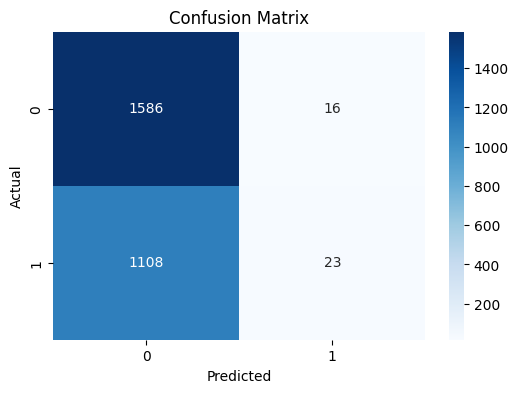

In [44]:
#Confusion Matrix
val_predictions = best_model.predict(X_val)

cm = confusion_matrix(y_val,val_predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
#Classification report
print(classification_report(y_val,val_predictions))

              precision    recall  f1-score   support

           0       0.59      0.99      0.74      1602
           1       0.59      0.02      0.04      1131

    accuracy                           0.59      2733
   macro avg       0.59      0.51      0.39      2733
weighted avg       0.59      0.59      0.45      2733



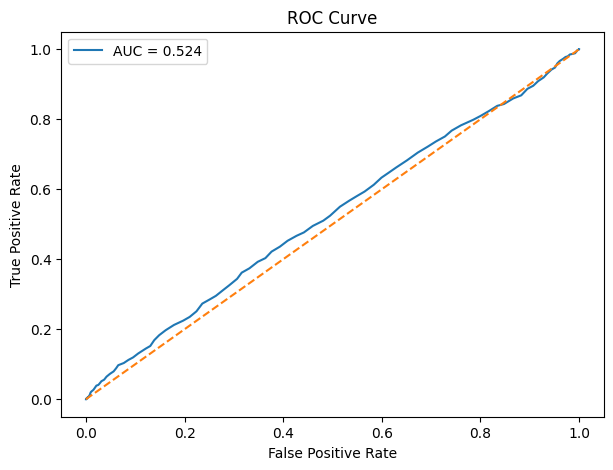

In [46]:
#ROC Curve
y_prob = best_model.predict_proba(X_val)[:,1]

fpr,tpr,_ = roc_curve(y_val,y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label="AUC = %.3f" % roc_auc_score(y_val,y_prob))
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [48]:
#Feature Importance
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

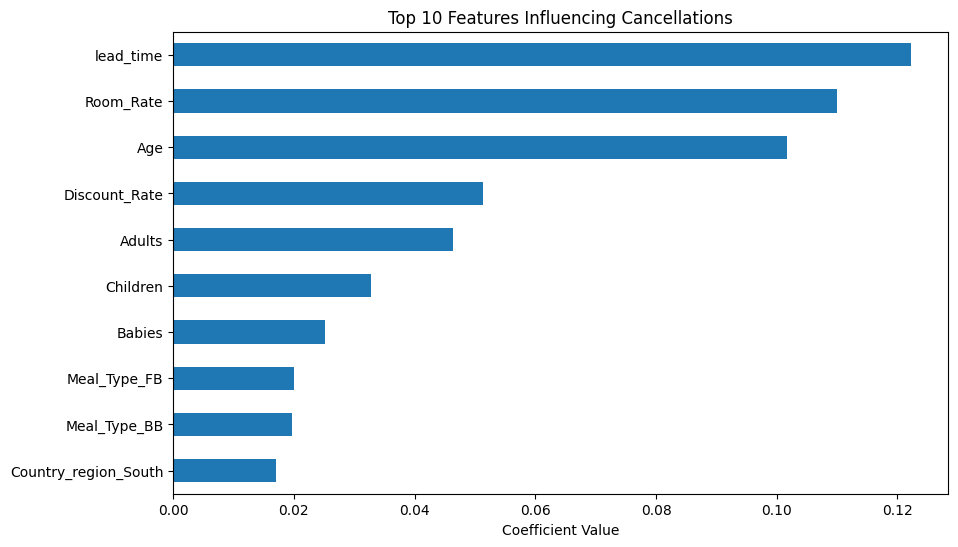

In [49]:
#Top 10 features influencing cancellations chart
plt.figure(figsize=(10,6))

importance.head(10).plot(kind="barh")

plt.title("Top 10 Features Influencing Cancellations")

plt.xlabel("Coefficient Value")

plt.gca().invert_yaxis()

plt.show()